<a href="https://colab.research.google.com/github/JGradone/Topics-Sentinel/blob/main/Rutgers_Topics_in_Marine_Science_Activity_4_Sentinel_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 4 - Sentinel Glider Data Deep Flight Eval
**2025 Rutgers University Topics in Marine Science**

*Written by Joe Gradone, Rutgers University, February 28, 2025*

## Imports

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from geopy.distance import geodesic

!pip install cartopy

import cartopy.crs as ccrs
import cartopy.feature as cfeature

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 70.2 MB/s eta 0:00:00


## Load Sentinel data

In [6]:
## This is a path to where this text file is stored on my GitHub
url = 'https://raw.githubusercontent.com/JGradone/Topics-Sentinel/main/Sentinel_Deep_Data.txt' # Changed URL to the correct path.

## Load the text file with the read_csv() function from pandas
sentinel_df = pd.read_csv(url)
## Reformat time
sentinel_df['time'] = pd.to_datetime(sentinel_df['time'])
## Take a peak at what it looks like
sentinel_df

,time,m_depth,m_pitch,m_roll,c_heading,m_heading,m_lon,m_lat,m_battery,m_de_oil_vol,c_de_oil_vol,pressure,conductivity,temperature,salinity
0,2025-02-24 23:32:55.305000192,1.881876,-0.881830,0.014929,NaN,3.646566,-117.475242,32.745789,NaN,-797.344091,-1175.0,0.604392,4.095964,14.987551,33.230883
1,2025-02-24 23:33:27.332999936,19.019686,-0.760983,0.019780,NaN,4.472695,-117.475319,32.745792,NaN,-1091.481904,-1175.0,1.889187,3.940738,13.184112,33.355073
2,2025-02-24 23:33:59.360000000,27.464075,-0.442637,0.020711,NaN,4.773062,-117.475552,32.746086,NaN,-1164.983519,-1175.0,2.952386,3.851593,12.090977,33.472726
3,2025-02-24 23:34:31.476000000,36.474442,-0.343436,0.018845,NaN,4.898522,-117.475837,32.746477,NaN,-1164.939612,-1175.0,3.844789,3.814017,11.551796,33.592548
4,2025-02-24 23:35:03.494999808,47.816639,-0.317414,0.016057,NaN,5.023604,-117.476121,32.746868,NaN,-1164.895837,-1175.0,4.740034,3.802437,11.303099,33.704755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16309,2025-03-03 11:15:53.712999936,1.293008,NaN,NaN,0.817367,NaN,-117.651028,32.734803,NaN,264.310788,262.5,NaN,NaN,NaN,NaN
16310,2025-03-03 11:17:29.987000064,0.045250,NaN,NaN,0.817281,NaN,-117.647102,32.741620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16311,2025-03-03 11:18:02.013999872,0.045250,NaN,NaN,0.817253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16312,2025-03-03 11:18:35.109999872,0.384623,NaN,NaN,0.817223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Load Slocum data

In [7]:
## This is a path to where this text file is stored on my GitHub
url = 'https://raw.githubusercontent.com/JGradone/Topics-Sentinel/main/Slocum_Deep_Data.txt' # Changed URL to the correct path on main branch.

## Load the text file with the read_csv() function from pandas
slocum_df = pd.read_csv(url)
## Reformat time
slocum_df['time'] = pd.to_datetime(slocum_df['time'])
## Take a peak at what it looks like
slocum_df

,time,m_depth,m_pitch,m_roll,c_heading,m_heading,m_lon,m_lat,m_battery,m_de_oil_vol,c_de_oil_vol,pressure,conductivity,temperature,salinity
0,2025-02-24 22:46:08.009999872,0.059912,-0.036886,-0.054760,NaN,NaN,-117.475464,32.742663,16.392509,NaN,-369.999976,0.012714,4.083535,15.456923,32.724219
1,2025-02-24 22:46:28.022000128,0.562032,-0.186275,-0.058031,NaN,NaN,-117.475420,32.742620,16.392509,NaN,-369.999996,0.090067,4.191963,15.851762,33.360054
2,2025-02-24 22:46:44.040999936,1.246742,-0.304551,-0.048871,NaN,5.379439,-117.475374,32.742594,16.392453,-241.699094,-370.000000,0.206957,4.182203,15.754126,33.355570
3,2025-02-24 22:47:00.053999872,3.871462,-0.421477,-0.027929,NaN,5.582321,-117.475319,32.742574,16.392379,-280.658375,-370.000000,0.469322,4.151639,15.446212,33.342913
4,2025-02-24 22:47:16.075000064,6.838537,-0.474292,-0.020508,NaN,5.785304,-117.475299,32.742594,16.392304,-319.637119,-370.000000,0.759978,4.118507,15.109967,33.330456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90862,2025-03-02 22:00:41.868999936,0.590184,-0.010148,-0.055593,2.373485,3.701102,-117.652903,32.766117,16.221501,371.216195,370.000000,0.001274,NaN,0.699804,NaN
90863,2025-03-02 22:01:13.135000064,0.088385,-0.031911,-0.054818,2.401693,3.790506,-117.652896,32.765948,16.221668,371.151141,370.000000,0.005353,NaN,2.939318,NaN
90864,2025-03-02 22:01:45.165999872,0.134003,-0.054207,-0.054024,2.430592,3.882097,-117.652889,32.765775,16.221838,371.090715,370.000000,0.009531,NaN,5.233628,NaN
90865,2025-03-02 22:02:17.188999936,0.248048,-0.076498,-0.053230,2.459483,3.973665,-117.652882,32.765603,16.222009,371.073781,370.000000,0.013708,NaN,7.527365,NaN


## Let's compare the two datasets now

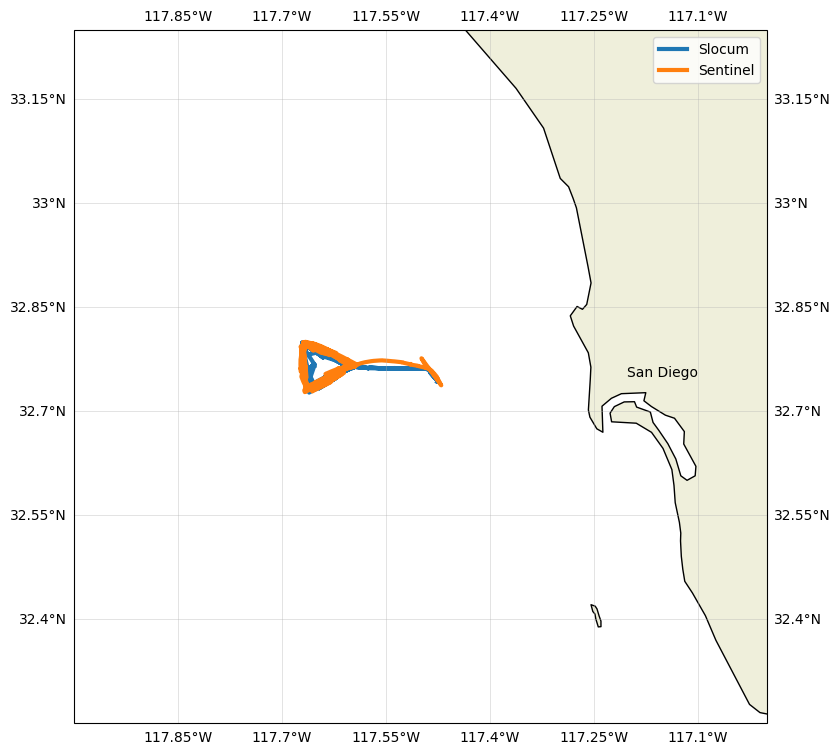

In [26]:
lon1 = -117
lon2 = -118
lat1 = 32.25
lat2 = 33.25


fig = plt.figure(figsize=(12,9))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon1, lon2, lat1, lat2])
LAND = cfeature.NaturalEarthFeature(
    'physical', 'land', '10m',
    edgecolor='black',
    facecolor=cfeature.COLORS['land']
)

ax.add_feature(LAND, zorder=0)

plt.plot(slocum_df.m_lon.values,slocum_df.m_lat.values,linewidth=3,label='Slocum',color='tab:blue')
plt.plot(sentinel_df.m_lon.values,sentinel_df.m_lat.values,linewidth=3,label='Sentinel',color='tab:orange')


glb = ax.gridlines(draw_labels=True, alpha=0.5, linewidth=.5 )


plt.text(-117.1, 32.75, 'San Diego',
         horizontalalignment='right',
         transform=ccrs.Geodetic())

plt.legend()
